In [315]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
import shap
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
import joblib
import importlib
from mis_funciones import * 
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression

# Datos del ejercicio
La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

1 age. Edad del beneficiario principal (numérico)\
2 sex. Género del beneficiario principal (categórico)\
3 bmi. índice de masa corporal (numérico)\
4 children. Número de niños/dependientes cubiertos por un seguro médico (numérico)\
5 smoker. ¿Es fumador? (categórico)\
6 region. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)\
7 charges. Prima del seguro médico (numérico)

In [316]:
df=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.548
1334,18,female,31.920,0,no,northeast,2205.981
1335,18,female,36.850,0,no,southeast,1629.833
1336,21,female,25.800,0,no,southwest,2007.945


# EDA

## Valores unicos

In [318]:
valores_unicos=df.nunique()
valores_unicos

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

## Filas y columnas duplicadas

In [319]:
df.duplicated().sum()

np.int64(1)

In [320]:
# Tenemos 1 duplicados los cuales eliminamos
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [321]:
df.T.duplicated().sum()

np.int64(0)

## Valores faltantes

In [322]:
promedio_faltantes=df.isna().mean()*100
faltantes = ["no hay valores faltantes"] if any(n == 0 for n in promedio_faltantes) else promedio_faltantes
faltantes

['no hay valores faltantes']

### valores faltantes enmascarados

In [323]:
# traemos el Df con solo columnas categoricas
df_cate = df.select_dtypes(include=['object'])
# sacamos la cantidad de unknown por columna
unknown_counts = df_cate.apply(lambda col: (col == "unknown").sum())
# sacamos el porcentaje de unknown
unknown_porce= df_cate.apply(lambda col: (col == "unknown").mean()*100)
# creamos un DF con esta info
df_result=pd.DataFrame({'unknown_counts':unknown_counts,'unknown_porcentaje':unknown_porce}).sort_values(by='unknown_counts',ascending=False)
df_result

,unknown_counts,unknown_porcentaje
sex,0,0.000
smoker,0,0.000
region,0,0.000


In [324]:
detectar_missing_ocultos(df,valores_sospechosos=[-1, 0, 999, 9999, -999])

,NaN reales,Valores no numéricos ocultos,Valores únicos
age,0,0,47
sex,0,1337,2
bmi,0,0,548
children,0,0,6
smoker,0,1337,2
region,0,1337,4
charges,0,0,1337


no tenemos valores faltantes enmascarados

## Tranin test split

In [325]:
y = df['charges']
X= df.drop('charges',axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Codificar de variables 

In [326]:
importlib.reload(mis_funciones)
X_train, X_test = encode_categorical(X_train, X_test)

## Outliers

In [328]:
pd.set_option('display.float_format', '{:.3f}'.format)
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1069.000,39.198,13.999,18.000,27.000,39.000,51.000,64.000
bmi,1069.000,30.540,6.052,15.960,26.180,30.200,34.430,53.130
children,1069.000,1.084,1.195,0.000,0.000,1.000,2.000,5.000
sex_male,1069.000,0.514,0.500,0.000,0.000,1.000,1.000,1.000
smoker_yes,1069.000,0.200,0.400,0.000,0.000,0.000,0.000,1.000
region_northwest,1069.000,0.247,0.431,0.000,0.000,0.000,0.000,1.000
region_southeast,1069.000,0.268,0.443,0.000,0.000,0.000,1.000,1.000
region_southwest,1069.000,0.248,0.432,0.000,0.000,0.000,0.000,1.000


In [329]:
iso = IsolationForest(random_state=123)
df_num = X_train.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train)
df_num['outlier_flag'].value_counts()

outlier_flag
-1    721
 1    348
Name: count, dtype: int64

Analizando los Outliers vemos que no es necesario tratarlos ya que los datos que nos dan no se salen de los parametros "normales" 

## Seleccion de caracteristicas

In [330]:
# Entrenamiento de RF
model = RandomForestRegressor(random_state=42,n_jobs=-1).fit(X_train, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()
df_rf_imp

,feature,rf_importance,rf_importance_acum
4,smoker_yes,60.078,60.078
1,bmi,21.609,81.687
0,age,13.573,95.259
2,children,2.294,97.553
3,sex_male,0.708,98.261
5,region_northwest,0.678,98.938
6,region_southeast,0.605,99.543
7,region_southwest,0.457,100.000


### Metodo 2 Permutation/Shuffle importance

In [331]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBRegressor(objective='reg:squarederror',random_state=42,use_label_encoder=False,eval_metric='rmse').fit(X_train1, y_train1)

# Realizamos 10 permutaciones por cada característica (se usa neg_mean_absolute_error)
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_root_mean_squared_error')

df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean}).sort_values('perm_imp', ascending=False)
df_perm_imp['perm_imp_pct'] = (
    df_perm_imp['perm_imp'] / df_perm_imp['perm_imp'].abs().sum()
) * 100
df_perm_imp

/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:01:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,feature,perm_imp,perm_imp_pct
4,smoker_yes,8499.982,62.982
1,bmi,2250.767,16.678
0,age,2131.525,15.794
2,children,470.315,3.485
5,region_northwest,24.088,0.178
7,region_southwest,-27.378,-0.203
6,region_southeast,-37.193,-0.276
3,sex_male,-54.536,-0.404


### Metodo 3 SHAP

In [332]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1).fit(X_train, y_train)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 8
[LightGBM] [Info] Start training from score 13030.203373


,feature,shap_imp
4,smoker_yes,47.627
0,age,23.784
1,bmi,14.413
2,children,6.328
7,region_southwest,2.966
6,region_southeast,1.917
3,sex_male,1.785
5,region_northwest,1.179


### Union de metodos

In [333]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp.drop(columns=['perm_imp']), on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_acum,perm_imp_pct,shap_imp
7,smoker_yes,60.078,60.078,62.982,47.627
1,bmi,21.609,81.687,16.678,14.413
0,age,13.573,95.259,15.794,23.784
2,children,2.294,97.553,3.485,6.328
6,sex_male,0.708,98.261,-0.404,1.785
3,region_northwest,0.678,98.938,0.178,1.179
4,region_southeast,0.605,99.543,-0.276,1.917
5,region_southwest,0.457,100.000,-0.203,2.966


### Caracteristicas pre-seleccionadas

In [334]:
df_filt = df_importances[(df_importances['rf_importance']>=2)|(df_importances['perm_imp_pct']>=2)|(df_importances['shap_imp']>=2)]
df_filt

,feature,rf_importance,rf_importance_acum,perm_imp_pct,shap_imp
7,smoker_yes,60.078,60.078,62.982,47.627
1,bmi,21.609,81.687,16.678,14.413
0,age,13.573,95.259,15.794,23.784
2,children,2.294,97.553,3.485,6.328
5,region_southwest,0.457,100.000,-0.203,2.966


aqui seleccionamos momentaneamente unas caracteristicas que tengan una que nos halla dado una impotancia mayor a 2 en cualquiera de los metodos aplicados

In [335]:
features=df_importances['feature']
features

7          smoker_yes
1                 bmi
0                 age
2            children
6            sex_male
3    region_northwest
4    region_southeast
5    region_southwest
Name: feature, dtype: object

## VIF

In [336]:
vif = pd.Series([variance_inflation_factor(X_train[features].corr().values, i) for i in range(X_train[features].corr().shape[1])], index=X_train[features].columns)
df_vif = pd.Series(vif, name='vif').reset_index().rename(columns={'index': 'feature'})
df_vif_filt=pd.merge(df_vif, df_filt, on='feature' ,how='inner')
print(df_vif)
print(df_vif_filt)


            feature   vif
0        smoker_yes 1.075
1               bmi 1.545
2               age 1.101
3          children 1.020
4          sex_male 1.046
5  region_northwest 4.580
6  region_southeast 5.721
7  region_southwest 4.653
            feature   vif  rf_importance  rf_importance_acum  perm_imp_pct  \
0        smoker_yes 1.075         60.078              60.078        62.982   
1               bmi 1.545         21.609              81.687        16.678   
2               age 1.101         13.573              95.259        15.794   
3          children 1.020          2.294              97.553         3.485   
4  region_southwest 4.653          0.457             100.000        -0.203   

   shap_imp  
0    47.627  
1    14.413  
2    23.784  
3     6.328  
4     2.966  


Aqui vemos que el VIF tanto en todas las variables como en las pre-seleccionadas no es alto 

## Matrix de correlacion

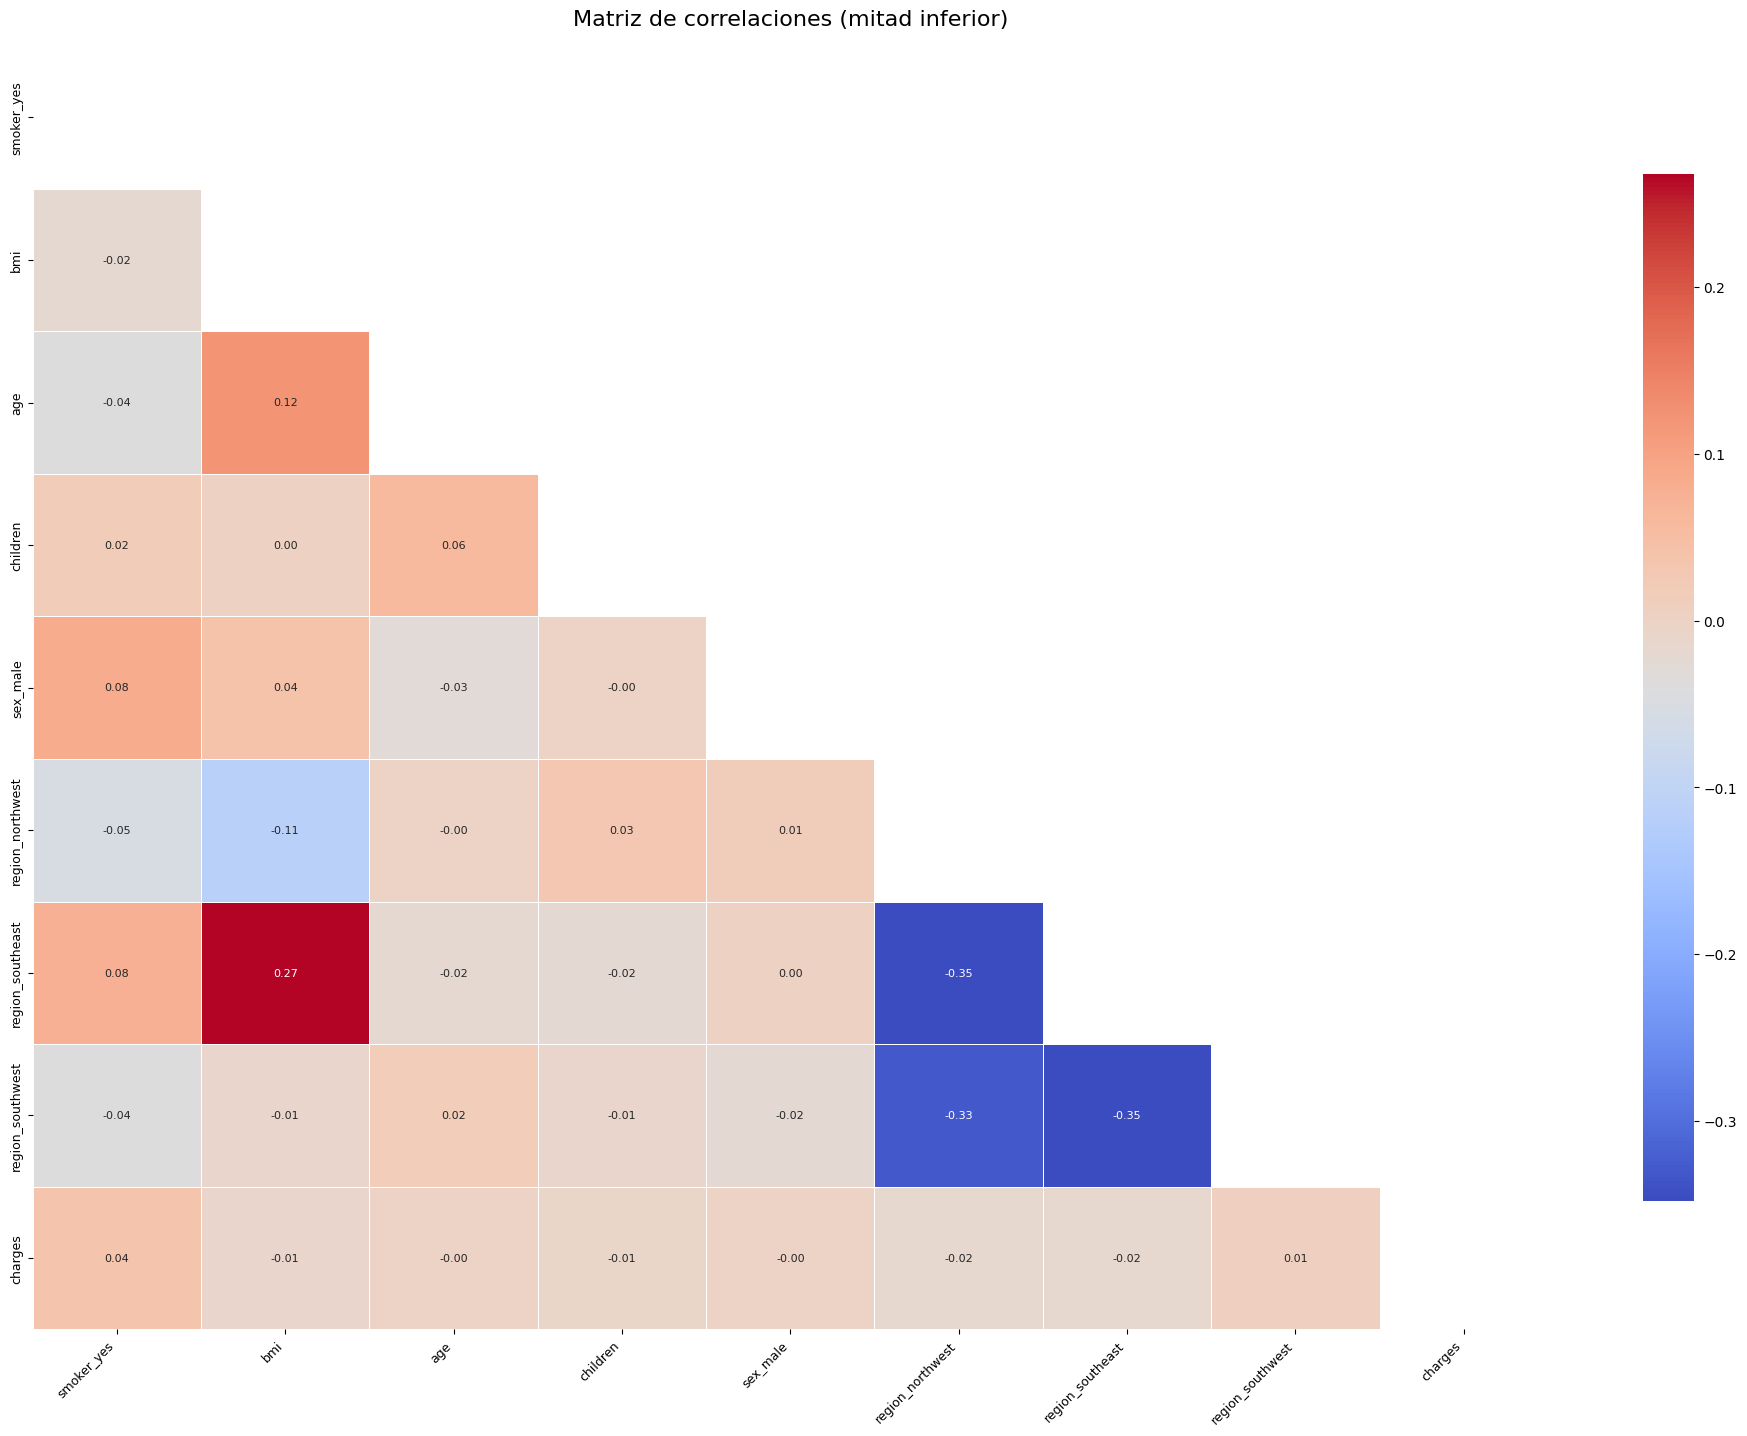

In [337]:
X_copy = X_train[features].copy()
X_copy['charges'] = y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

vemos que no existe una correalaccion alta entre las variables por lo que de acuedo a esto haremos un cross_validation para ver si es mejor conservarlas todas o con las pre-selecionadas.

### Cross_validation y seleccion final

In [338]:
# Versión 1: Realizar cross_validation con todas las características 
cv_results1 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features], y_train, cv=3, scoring='r2')
cv_results1.mean()*1

np.float64(0.8214900362167779)

In [339]:
# Version 2: con las caracteristicas pre-seleccionadas
cv_results2 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features].drop(['region_southeast','region_northwest','sex_male'],axis=1), y_train, cv=3, scoring='r2')
cv_results2.mean()*1

np.float64(0.816984088927811)

Decidimos quedarnos con todas las caracteristicas ya que ninguna presenta un vif alto, no hay una gran correlacion entre ellas y realizando el cross validation nos da un R2 mas alto

### Escalamos

para los metodos anteriores no era necesario tener los datos escalados ya que son modelos que estan basados en arboles y trabaja muy bien con los datos asi, sin embargo para el modelo del presente proyecto si sera necesrio escalar los datos.

In [340]:
scaler = StandardScaler()

cols_to_scale = ['age', 'bmi', 'children']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


# Modelacion

## Regresion lineal

In [341]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [342]:
print(f"Intercepto (a): {model_lr.intercept_}")
print(f"Coeficientes (b): {model_lr.coef_}")

Intercepto (a): 8947.95219506918
Coeficientes (b): [ 3472.97555343  1927.82825101   636.5011853   -101.54205399
 23077.76459287  -391.76145478  -838.91961573  -659.13975155]


In [343]:
y_pred = model_lr.predict(X_test)
y_pred

array([222427.26533065, 160903.51146003, 257731.47843411, 207402.17254362,
       190952.06160855, 251769.13270941, 183870.61885195, 131540.50111852,
       226791.28142813, 235849.34688174, 261065.59731333, 264872.52300517,
       208528.75771047, 304964.76424719, 205215.71615794, 221072.84346846,
       141901.61492675, 224608.43066255, 145447.16669824, 166506.2627615 ,
       141186.87593127, 211615.18257728, 261837.54682112, 221905.12225505,
       214737.88635473, 147594.54381437, 256151.19928014, 302876.33482133,
       239098.80906453, 246774.12288914, 176498.17896902, 253757.36264709,
       116114.50648594, 266744.60612998, 310125.81443782, 251978.79303829,
       132593.74186406, 153115.13450673, 255444.56989613, 222577.99166326,
       162090.61790198, 221279.98524753, 251676.68966043, 248873.51705894,
       208046.24217632, 155270.09681561, 149114.43410748, 215905.32713151,
       156434.23311157, 207072.50511738, 170243.68272931, 226523.97077168,
       230716.38667375, 1

In [344]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred)}")

Error cuadrático medio: 40903398203.65909
Coeficiente de determinación: -221.59618161232774
